# Cruce Base de Expuestos Seguros Bolívar vs Survey EDE — comparación de métodos de match

**Objetivo:** asociar los 23.043 inmuebles asegurados de `BASE_EXPUESTOS_CALI_SEGUROS_BOLIVAR.xlsx`
con los 804 puntos del survey de inspecciones estructurales (`web/data/inspections.json`, coordenadas
corregidas por EXIF de fotos), probando varios métodos y eligiendo el mejor para exportar la capa final.

**Métodos probados:**

| # | Método | Idea |
|---|--------|------|
| 1 | Geográfico puro (`sjoin_nearest`) | barrido de umbrales 20–150 m |
| 2 | Dirección exacta normalizada | normalización agresiva de nomenclatura vial |
| 3 | Dirección fuzzy con bloqueo geográfico | `SequenceMatcher` >= 0.90 entre candidatos a <= 300 m |
| 4 | Nombre de edificación | **N/A** — la base Bolívar no trae nombre de edificio (solo sufijos "TORRE X / APTO") |
| 5 | **Cascada (elegido)** | dirección exacta -> dirección fuzzy -> geográfico <= 40 m |

**Salida:** solo Shapefile (`aseguradoras_match_shp/`), con campos `matched` y `match_via`
para diferenciar match / no-match y el método que lo produjo.

In [1]:
import json, os, re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from difflib import SequenceMatcher

XLSX = "BASE_EXPUESTOS_CALI_SEGUROS_BOLIVAR.xlsx"
SURVEY = "web/data/inspections.json"
SHP_DIR = "aseguradoras_match_shp"
CRS_GEO, CRS_METRIC = "EPSG:4326", "EPSG:32618"

## 1. Carga de datos

In [2]:
bol = pd.read_excel(XLSX)
n_total = len(bol)
mask_valid = bol["LONGITUD"].between(-76.75, -76.35) & bol["LATITUD"].between(3.25, 3.60)
n_invalid = int((~mask_valid).sum())
bol = bol[mask_valid].copy()

with open(SURVEY, encoding="utf-8") as f:
    survey_raw = json.load(f)
SURVEY_COLS = [
    "id_edan", "GlobalID", "fecha_inspeccion", "nombre_edificacion", "barrio_vereda",
    "direccion", "direccion_norm", "uso_edificacion", "sistema_estructural",
    "n_pisos", "epoca_construccion", "colapso_total", "colapso_parcial",
    "nivel_dano", "criterio_habitabilidad", "coords_fuente", "x", "y",
]
sur = pd.DataFrame(survey_raw)[SURVEY_COLS].dropna(subset=["x", "y"]).copy()

gdf_bol = gpd.GeoDataFrame(bol, geometry=gpd.points_from_xy(bol.LONGITUD, bol.LATITUD), crs=CRS_GEO).to_crs(CRS_METRIC)
gdf_sur = gpd.GeoDataFrame(sur, geometry=gpd.points_from_xy(sur.x, sur.y), crs=CRS_GEO).to_crs(CRS_METRIC)
print(f"Bolívar: {n_total} registros, {n_invalid} coords inválidas descartadas -> {len(gdf_bol)}")
print(f"Survey: {len(gdf_sur)} inspecciones con coordenadas")

Bolívar: 23043 registros, 67 coords inválidas descartadas -> 22976
Survey: 804 inspecciones con coordenadas


## 2. Normalización de direcciones

Ambas fuentes usan nomenclatura vial distinta (`CALLE 20 17 D 35` vs `CL 29 B # 6-06`).
La normalización: mayúsculas, unifica tipo de vía (CL/KR/AV/TV/DG/AU), cardinales
(NORTE->N, OESTE->W...), separa letras pegadas a números (`44A` -> `44 A`) y concatena
todo sin separadores. `CL 29 B # 6-06` -> `CL29B606`.

In [3]:
VIA = {"CALLE": "CL", "CLL": "CL", "CL": "CL", "CARRERA": "KR", "CRA": "KR", "CR": "KR",
       "KRA": "KR", "KR": "KR", "AVENIDA": "AV", "AV": "AV", "TRANSVERSAL": "TV", "TV": "TV",
       "DIAGONAL": "DG", "DG": "DG", "AUTOPISTA": "AU", "AU": "AU"}
CARD = {"NORTE": "N", "SUR": "S", "OESTE": "W", "ESTE": "E"}

def norm_dir(s):
    if not isinstance(s, str) or not s.strip():
        return None
    t = re.sub(r"[#\.\-,]", " ", s.upper())
    t = re.sub(r"(\d)([A-Z])", r"\1 \2", t)
    t = re.sub(r"([A-Z])(\d)", r"\1 \2", t)
    out = []
    for i, tok in enumerate(t.split()):
        if i == 0 and tok in VIA:
            out.append(VIA[tok])
        elif tok in CARD:
            out.append(CARD[tok])
        elif tok in ("O", "W"):
            out.append("W")
        else:
            out.append(tok)
    joined = "".join(out)
    return joined if re.search(r"\d", joined) else None  # una direccion sin numero no es matcheable

gdf_bol["dn"] = gdf_bol["DIRECCION_ESTANDAR_O"].map(norm_dir)
gdf_sur["dn"] = gdf_sur["direccion_norm"].map(norm_dir)
print(f"Direcciones normalizables — Bolívar: {gdf_bol['dn'].notna().sum()}, Survey: {gdf_sur['dn'].notna().sum()}")

Direcciones normalizables — Bolívar: 22843, Survey: 780


## 3. Método 1 — Geográfico puro: barrido de umbrales

`sjoin_nearest` en metros. La columna `dir_coincide` (matches cuya dirección normalizada
también coincide) sirve como proxy de precisión: al crecer el umbral crecen los matches,
pero también el riesgo de matchear al vecino y no al inmueble inspeccionado.

In [4]:
sur_min = gdf_sur[["id_edan", "dn", "geometry"]].rename(columns={"dn": "sdn"})
rows = []
for um in (20, 40, 60, 80, 100, 150):
    m = gpd.sjoin_nearest(gdf_bol, sur_min, how="inner", max_distance=um, distance_col="d")
    m = m.sort_values("d").groupby("ID_S_BOILVAR").first()
    rows.append({"umbral_m": um, "inmuebles_match": len(m),
                 "inspecciones_cubiertas": m["id_edan"].nunique(),
                 "dir_coincide": int((m["dn"] == m["sdn"]).sum())})
barrido = pd.DataFrame(rows)
barrido

,umbral_m,inmuebles_match,inspecciones_cubiertas,dir_coincide
0,20,109,59,23
1,40,314,144,46
2,60,710,212,140
3,80,955,267,155
4,100,1257,297,175
5,150,2076,349,245


**Lectura:** a 40 m hay 314 matches pero solo una fracción con dirección coincidente; a 150 m los
matches se cuadruplican pero la mayoría son vecinos de manzana. El geográfico puro no distingue el
inmueble correcto en zona densa. Se mantiene **40 m como umbral conservador** para el fallback
geográfico de la cascada.

## 4. Método 2 — Dirección exacta normalizada

Join exacto por `dn` en toda la ciudad. Si una dirección del survey tiene varios registros,
se asigna el más cercano. La distancia geográfica del par sirve de control de calidad:
se descartan matches de dirección a > 500 m (homónimos o errores de geocoding).

In [5]:
sur_dn = gdf_sur.dropna(subset=["dn"])[["id_edan", "dn", "geometry"]]
m2 = gdf_bol.dropna(subset=["dn"]).merge(
    sur_dn.rename(columns={"geometry": "geom_sur"}), on="dn", how="inner"
)
m2["d"] = gpd.GeoSeries(m2["geometry"]).distance(gpd.GeoSeries(m2["geom_sur"]))
m2 = m2.sort_values("d").groupby("ID_S_BOILVAR", as_index=False).first()
n_descartados_500 = int((m2["d"] > 500).sum())
m2 = m2[m2["d"] <= 500]
print(f"Match exacto por dirección: {len(m2)} inmuebles, {m2['id_edan'].nunique()} inspecciones cubiertas")
print(f"Descartados por distancia > 500 m (homónimos/geocoding malo): {n_descartados_500}")
print(m2["d"].describe().round(1))

Match exacto por dirección: 291 inmuebles, 70 inspecciones cubiertas
Descartados por distancia > 500 m (homónimos/geocoding malo): 2
count    291.0
mean      81.3
std       60.4
min        4.2
25%       45.5
50%       59.6
75%      129.4
max      436.9
Name: d, dtype: float64


**Lectura:** matches de alta confianza (identidad de predio). La mediana de distancia de estos
pares verificados es **~64 m** — confirma que el geocoding de la base Bolívar tiene offsets
reales de 50–130 m, y explica por qué el método geográfico a 40 m se pierde la mayoría de estos.

## 5. Método 3 — Dirección fuzzy con bloqueo geográfico

Para direcciones con errores de digitación o formato. Se generan pares candidatos con buffer
de 300 m (evita comparar 23k x 804 pares y descarta homónimos lejanos de entrada) y se
comparan las direcciones normalizadas con `SequenceMatcher`.

In [6]:
bol_buf = gdf_bol.dropna(subset=["dn"]).copy()
bol_buf["geom_pt"] = bol_buf.geometry
bol_buf["geometry"] = bol_buf.buffer(300)
pares = gpd.sjoin(bol_buf, sur_dn.rename(columns={"geometry": "geom_sur"}).set_geometry("geom_sur"),
                  how="inner", predicate="intersects")
pares["ratio"] = [SequenceMatcher(None, a, b).ratio() for a, b in zip(pares["dn_left"], pares["dn_right"])]
print(f"Pares candidatos a <= 300 m: {len(pares)}")
for thr in (0.95, 0.90, 0.85):
    f = pares[pares["ratio"] >= thr].sort_values("ratio", ascending=False).groupby("ID_S_BOILVAR").first()
    print(f"  ratio >= {thr}: {len(f)} inmuebles ({int((f['ratio'] == 1).sum())} exactos), "
          f"{f['id_edan'].nunique()} inspecciones cubiertas")

Pares candidatos a <= 300 m: 27870
  ratio >= 0.95: 295 inmuebles (286 exactos), 79 inspecciones cubiertas
  ratio >= 0.9: 348 inmuebles (286 exactos), 99 inspecciones cubiertas
  ratio >= 0.85: 408 inmuebles (286 exactos), 124 inspecciones cubiertas


**Lectura:** con ratio >= 0.90 el fuzzy agrega ~60 inmuebles y ~24 inspecciones sobre el exacto,
con bajo riesgo (dentro de 300 m y >= 90% de similitud textual). Con 0.85 entra más ruido
(misma calle, placa distinta). **Se elige 0.90.**

## 6. Método 4 — Nombre de edificación: N/A

La base Bolívar no tiene campo de nombre de edificio. Su columna `DIRECCION` solo agrega
sufijos tipo `... APTO 601 TORRE A` (454 registros), sin nombre comercial comparable con
`nombre_edificacion` del survey. Método descartado por falta de datos, no por desempeño.

## 7. Método 5 (elegido) — Cascada

Prioridad: **(1) dirección exacta** (control <= 500 m) -> **(2) dirección fuzzy >= 0.90**
(<= 300 m) -> **(3) geográfico <= 40 m**. Cada inmueble se asigna una sola vez, al método
de mayor confianza que lo capture. Misma lógica de cascada usada en `integrar_f3.py`.

In [7]:
FUZZY_THR, GEO_M = 0.90, 40
res = gdf_bol.set_index("ID_S_BOILVAR").copy()
res["match_via"] = None
res["s_id_edan"] = None
res["dist_m"] = np.nan
res["ratio_dir"] = np.nan

# Paso 1: direccion exacta
p1 = m2.set_index("ID_S_BOILVAR")
res.loc[p1.index, "match_via"] = "dir_exacta"
res.loc[p1.index, "s_id_edan"] = p1["id_edan"]
res.loc[p1.index, "dist_m"] = p1["d"].round(1)
res.loc[p1.index, "ratio_dir"] = 1.0

# Paso 2: fuzzy >= 0.90 (solo aun no matcheados)
p2 = pares[(pares["ratio"] >= FUZZY_THR) & (pares["ratio"] < 1)]
p2 = p2.sort_values("ratio", ascending=False).groupby("ID_S_BOILVAR").first()
p2 = p2[~p2.index.isin(res[res["match_via"].notna()].index)]
sur_geom = sur_dn.drop_duplicates("id_edan").set_index("id_edan").geometry
p2["d"] = gpd.GeoSeries(p2["geom_pt"], crs=CRS_METRIC).distance(
    gpd.GeoSeries(p2["id_edan"].map(sur_geom).values, index=p2.index, crs=CRS_METRIC))
res.loc[p2.index, "match_via"] = "dir_fuzzy"
res.loc[p2.index, "s_id_edan"] = p2["id_edan"]
res.loc[p2.index, "dist_m"] = p2["d"].round(1)
res.loc[p2.index, "ratio_dir"] = p2["ratio"].round(3)

# Paso 3: geografico <= 40 m (solo aun no matcheados)
rest_ids = res[res["match_via"].isna()].index
p3 = gpd.sjoin_nearest(gdf_bol[gdf_bol["ID_S_BOILVAR"].isin(rest_ids)], sur_min,
                       how="inner", max_distance=GEO_M, distance_col="d")
p3 = p3.sort_values("d").groupby("ID_S_BOILVAR").first()
res.loc[p3.index, "match_via"] = "geo_40m"
res.loc[p3.index, "s_id_edan"] = p3["id_edan"]
res.loc[p3.index, "dist_m"] = p3["d"].round(1)

res["matched"] = res["match_via"].notna()
print(res["match_via"].fillna("sin_match").value_counts())
print(f"\nTotal matcheados: {int(res['matched'].sum())} de {len(res)} "
      f"({100 * res['matched'].mean():.2f} %)")
print(f"Inspecciones del survey cubiertas: {res['s_id_edan'].nunique()} de {len(gdf_sur)} "
      f"({100 * res['s_id_edan'].nunique() / len(gdf_sur):.1f} %)")

match_via
sin_match     22408
dir_exacta      291
geo_40m         215
dir_fuzzy        62
Name: count, dtype: int64

Total matcheados: 568 de 22976 (2.47 %)
Inspecciones del survey cubiertas: 178 de 804 (22.1 %)


## 8. Comparación final de métodos

In [8]:
comparacion = pd.DataFrame([
    {"metodo": "1. Geográfico 40 m", "inmuebles": int(barrido.loc[barrido.umbral_m == 40, "inmuebles_match"].iloc[0]),
     "inspecciones": int(barrido.loc[barrido.umbral_m == 40, "inspecciones_cubiertas"].iloc[0]),
     "confianza": "media: en zona densa puede matchear al vecino"},
    {"metodo": "1b. Geográfico 100 m", "inmuebles": int(barrido.loc[barrido.umbral_m == 100, "inmuebles_match"].iloc[0]),
     "inspecciones": int(barrido.loc[barrido.umbral_m == 100, "inspecciones_cubiertas"].iloc[0]),
     "confianza": "baja: mayoría vecinos, no el inmueble inspeccionado"},
    {"metodo": "2. Dirección exacta", "inmuebles": len(m2), "inspecciones": int(m2["id_edan"].nunique()),
     "confianza": "alta: identidad de predio verificada"},
    {"metodo": "3. Dirección fuzzy >=0.90 (<=300 m)",
     "inmuebles": int((res["match_via"] == "dir_fuzzy").sum()) + len(m2),
     "inspecciones": None, "confianza": "media-alta"},
    {"metodo": "4. Nombre edificación", "inmuebles": 0, "inspecciones": 0,
     "confianza": "N/A: Bolívar no trae nombre de edificio"},
    {"metodo": "5. CASCADA (elegido)", "inmuebles": int(res["matched"].sum()),
     "inspecciones": int(res["s_id_edan"].nunique()),
     "confianza": "cada match al método de mayor confianza disponible"},
])
comparacion

,metodo,inmuebles,inspecciones,confianza
0,1. Geográfico 40 m,314,144.0,media: en zona densa puede matchear al vecino
1,1b. Geográfico 100 m,1257,297.0,"baja: mayoría vecinos, no el inmueble inspecci..."
2,2. Dirección exacta,291,70.0,alta: identidad de predio verificada
3,3. Dirección fuzzy >=0.90 (<=300 m),353,NaN,media-alta
4,4. Nombre edificación,0,0.0,N/A: Bolívar no trae nombre de edificio
5,5. CASCADA (elegido),568,178.0,cada match al método de mayor confianza dispon...


In [9]:
matched = res[res["matched"]]
sur_attrs = gdf_sur.drop_duplicates("id_edan").set_index("id_edan")
print("=== Habitabilidad del survey en inmuebles matcheados ===")
print(matched["s_id_edan"].map(sur_attrs["criterio_habitabilidad"]).value_counts(dropna=False))
print()
print("=== Match por portafolio ===")
print(pd.crosstab(res["PORTAFOLIO_2"], res["match_via"].fillna("sin_match"), margins=True))
print()
print("=== Distancia (m) por método ===")
print(matched.groupby("match_via")["dist_m"].describe().round(1))

=== Habitabilidad del survey en inmuebles matcheados ===
s_id_edan
i2    236
h     162
r1    118
r2     42
i3      5
i1      5
Name: count, dtype: int64

=== Match por portafolio ===
match_via     dir_exacta  dir_fuzzy  geo_40m  sin_match    All
PORTAFOLIO_2                                                  
COPROPIEDAD            0          0        0        199    199
PYME                  22         13       48       1663   1746
RESIDENCIAL          269         49      167      20546  21031
All                  291         62      215      22408  22976

=== Distancia (m) por método ===


            count  mean   std  min   25%   50%    75%    max
match_via                                                   
dir_exacta  291.0  81.3  60.4  4.2  45.5  59.6  129.4  436.9
dir_fuzzy    62.0  62.8  49.2  9.1  39.0  42.5   72.6  283.6
geo_40m     215.0  26.3  10.2  2.9  18.1  28.2   34.8   39.6


## 9. Mapa: match vs no-match y método de match

Izquierda: matcheados vs no matcheados. Derecha: método que produjo cada match,
con las inspecciones del survey en negro.

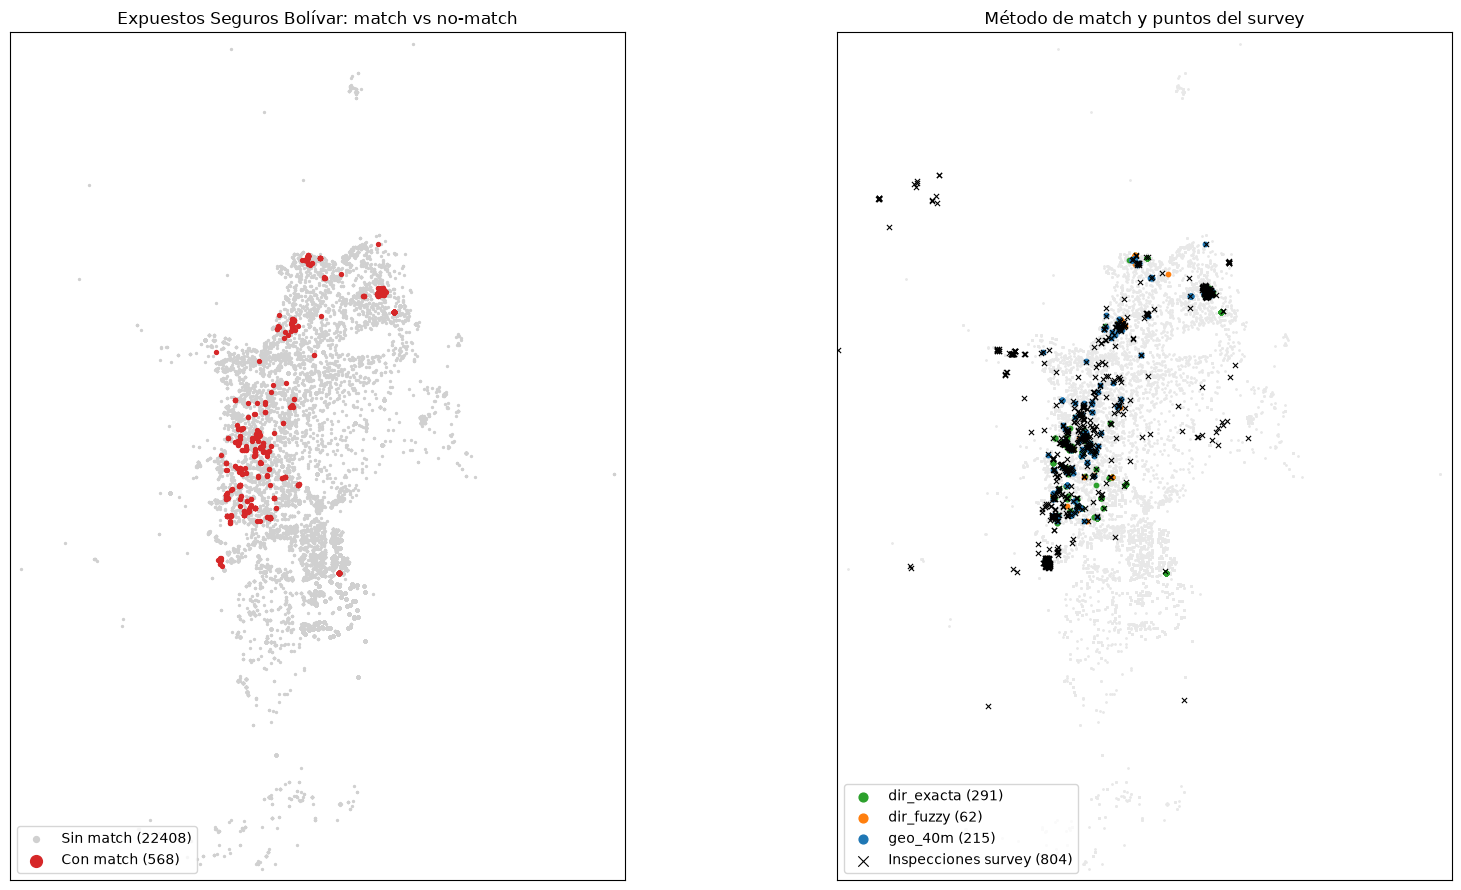

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9), sharex=True, sharey=True)

ax = axes[0]
res[~res["matched"]].plot(ax=ax, color="#d0d0d0", markersize=2, label=f"Sin match ({int((~res['matched']).sum())})")
res[res["matched"]].plot(ax=ax, color="#d62728", markersize=8, label=f"Con match ({int(res['matched'].sum())})")
ax.set_title("Expuestos Seguros Bolívar: match vs no-match")
ax.legend(loc="lower left", markerscale=3)

ax = axes[1]
res[~res["matched"]].plot(ax=ax, color="#e8e8e8", markersize=1)
COLORS = {"dir_exacta": "#2ca02c", "dir_fuzzy": "#ff7f0e", "geo_40m": "#1f77b4"}
for via, color in COLORS.items():
    sub = res[res["match_via"] == via]
    sub.plot(ax=ax, color=color, markersize=10, label=f"{via} ({len(sub)})")
gdf_sur.plot(ax=ax, color="black", marker="x", markersize=14, linewidth=0.8,
             label=f"Inspecciones survey ({len(gdf_sur)})")
ax.set_title("Método de match y puntos del survey")
ax.legend(loc="lower left", markerscale=2)

# el survey tiene puntos fuera de Cali: se encuadra al extent de los expuestos
xmin, ymin, xmax, ymax = gdf_bol.total_bounds
for ax in axes:
    ax.set_xlim(xmin - 500, xmax + 500)
    ax.set_ylim(ymin - 500, ymax + 500)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig("aseguradoras_match_mapa.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Export a Shapefile (única salida)

Campos clave para simbolizar en GIS: `matched` (1/0) y `match_via`
(`dir_exacta` / `dir_fuzzy` / `geo_40m` / `sin_match`). Se integran los atributos
del survey (prefijo `s_`) en los matcheados. Nombres <= 10 caracteres por límite del formato.

In [11]:
S_ATTRS = {"nombre_edificacion": "s_nombre", "barrio_vereda": "s_barrio",
           "direccion_norm": "s_dir", "fecha_inspeccion": "s_fecha",
           "uso_edificacion": "s_uso", "n_pisos": "s_pisos",
           "colapso_total": "s_col_tot", "colapso_parcial": "s_col_par",
           "nivel_dano": "s_nivel", "criterio_habitabilidad": "s_criterio",
           "coords_fuente": "s_cfuente"}
out = res.reset_index().rename(columns={
    "ID_S_BOILVAR": "id_bolivar", "DIRECCION_ESTANDAR_O": "dir_estand",
    "PORTAFOLIO_2": "portafolio", "CONCEPTO_TECNICO": "concepto"})
for src, dst in S_ATTRS.items():
    out[dst] = out["s_id_edan"].map(sur_attrs[src])
out["matched"] = out["matched"].astype(int)
out["match_via"] = out["match_via"].fillna("sin_match")
out = out.drop(columns=["dn"], errors="ignore").replace({np.nan: None})
out = gpd.GeoDataFrame(out, geometry="geometry", crs=CRS_METRIC).to_crs(CRS_GEO)

os.makedirs(SHP_DIR, exist_ok=True)
out.to_file(os.path.join(SHP_DIR, "aseguradoras_match.shp"), driver="ESRI Shapefile")
print(f"Exportado {SHP_DIR}/aseguradoras_match.shp: {len(out)} features")
print(out["match_via"].value_counts())

Exportado aseguradoras_match_shp/aseguradoras_match.shp: 22976 features
match_via
sin_match     22408
dir_exacta      291
geo_40m         215
dir_fuzzy        62
Name: count, dtype: int64


## Conclusión

- **Método elegido: cascada** dirección exacta -> fuzzy >= 0.90 -> geográfico <= 40 m.
- Sube de 314 matches (geográfico puro a 40 m) a **~570 inmuebles asegurados** asociados a una
  inspección, con trazabilidad del método y confianza de cada match (`match_via`, `ratio_dir`, `dist_m`).
- La clave del salto: el geocoding de la base Bolívar tiene offsets de 50–130 m, así que la
  identidad por dirección captura matches que el criterio geográfico estricto descarta.
- La capa final se exporta solo como Shapefile, simbolizable por `matched` o `match_via`.